# Price distribution in `usa_housing_dataset`

Visualize the distribution of `price` and highlight the **upper 0.1% outliers**
(prices above the 99.9th percentile).


In [5]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

# Resolve the dataset relative to this notebook so it works regardless of cwd.
csv_path = Path("raw/usa_housing_dataset.csv")
if not csv_path.exists():
    csv_path = (
        Path(__file__).parent / csv_path
        if "__file__" in globals()
        else Path.cwd() / csv_path
    )

df = pd.read_csv(csv_path)
price = df["price"]

print(f"n = {len(price):,}  (zero-priced rows: {(price == 0).sum()})")
price.describe().apply(lambda v: f"{v:,.0f}")

n = 4,140  (zero-priced rows: 49)


count         4,140
mean        553,063
std         583,686
min               0
25%         320,000
50%         460,000
75%         659,125
max      26,590,000
Name: price, dtype: str

In [6]:
# Upper 0.1% threshold = 99.9th percentile.
OUTLIER_Q = 0.999
threshold = price.quantile(OUTLIER_Q)
outliers = df.loc[price > threshold].sort_values("price", ascending=False)

print(
    f"Upper {(1 - OUTLIER_Q) * 100:.2f}% threshold (q={OUTLIER_Q}): ${threshold:,.0f}"
)
print(f"Outliers above threshold: {len(outliers)}")
outliers[["price", "bedrooms", "bathrooms", "sqft_living", "city", "statezip"]]

Upper 0.10% threshold (q=0.999): $4,393,229
Outliers above threshold: 5


,price,bedrooms,bathrooms,sqft_living,city,statezip
3890,26590000.0,3.0,2.00,1180,Kent,WA 98031
3886,12899000.0,3.0,2.50,2190,Seattle,WA 98199
1826,7062500.0,5.0,4.50,10040,Bellevue,WA 98004
2194,4668000.0,5.0,6.75,9640,Mercer Island,WA 98040
2301,4489000.0,4.0,3.00,6430,Bellevue,WA 98004


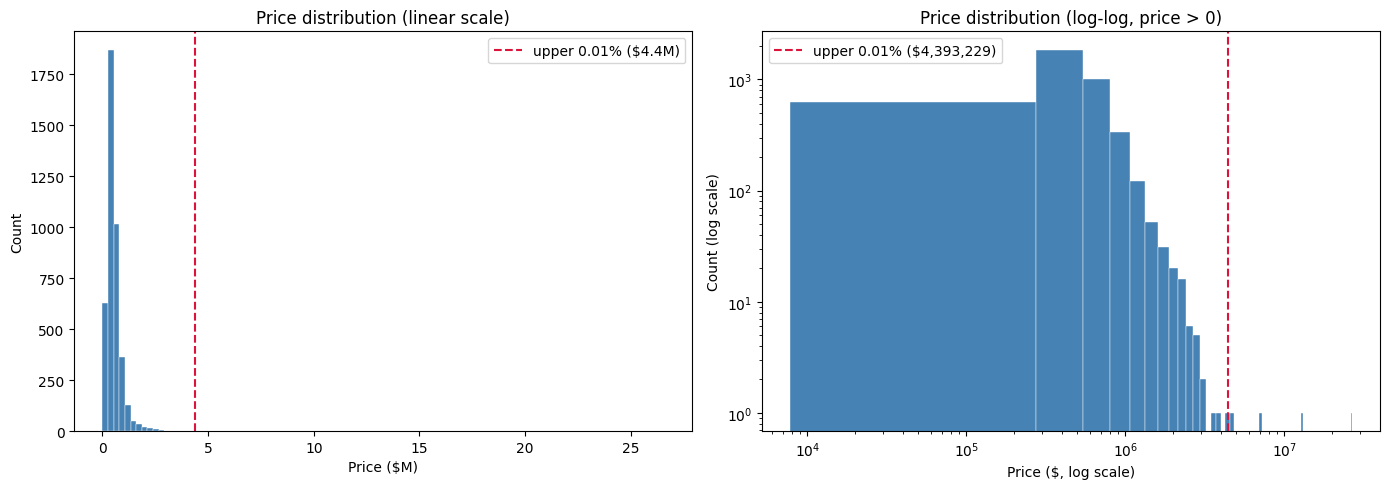

In [7]:
# Full distribution with the upper-0.01% region marked.
fig, (ax_lin, ax_log) = plt.subplots(1, 2, figsize=(14, 5))

# Linear scale: the long right tail makes the bulk hard to see, but it shows
# how far the outliers sit from the mass of the data.
ax_lin.hist(price / 1e6, bins=100, color="steelblue", edgecolor="white", linewidth=0.3)
ax_lin.axvline(
    threshold / 1e6,
    color="crimson",
    linestyle="--",
    label=f"upper 0.01% (${threshold/1e6:.1f}M)",
)
ax_lin.set_title("Price distribution (linear scale)")
ax_lin.set_xlabel("Price ($M)")
ax_lin.set_ylabel("Count")
ax_lin.legend()

# Log scale on the x-axis spreads out the tail so the shape is readable.
positive = price[price > 0]
ax_log.hist(positive, bins=100, color="steelblue", edgecolor="white", linewidth=0.3)
ax_log.axvline(
    threshold, color="crimson", linestyle="--", label=f"upper 0.01% (${threshold:,.0f})"
)
ax_log.set_xscale("log")
ax_log.set_yscale("log")
ax_log.set_title("Price distribution (log-log, price > 0)")
ax_log.set_xlabel("Price ($, log scale)")
ax_log.set_ylabel("Count (log scale)")
ax_log.legend()

fig.tight_layout()
plt.show()

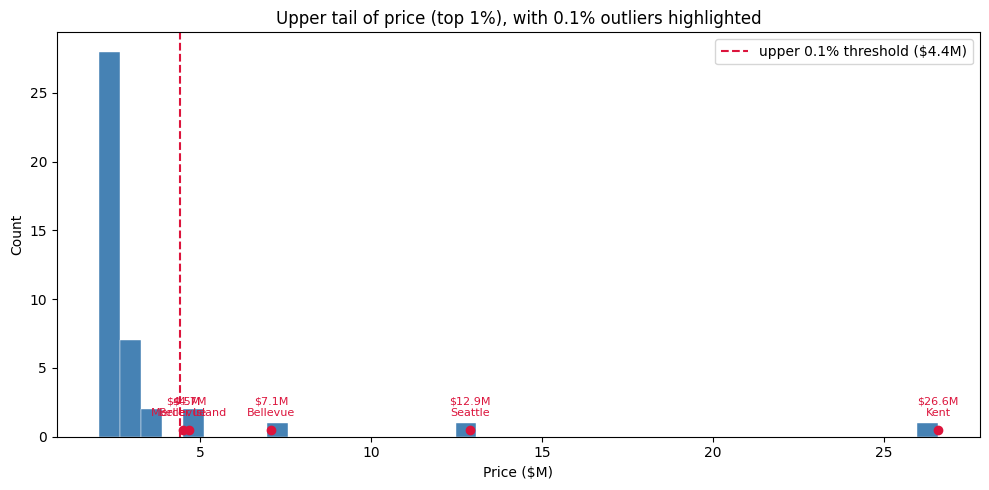

In [8]:
# Zoom on the upper tail (top 1%) to see where the 0.01% outliers land.
tail = price[price > price.quantile(0.99)]

fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(tail / 1e6, bins=40, color="steelblue", edgecolor="white", linewidth=0.3)
ax.axvline(
    threshold / 1e6,
    color="crimson",
    linestyle="--",
    label=f"upper 0.1% threshold (${threshold/1e6:.1f}M)",
)
for _, row in outliers.iterrows():
    ax.scatter(row["price"] / 1e6, 0.5, color="crimson", zorder=3)
    ax.annotate(
        f"${row['price']/1e6:.1f}M\n{row['city']}",
        (row["price"] / 1e6, 0.5),
        textcoords="offset points",
        xytext=(0, 10),
        ha="center",
        fontsize=8,
        color="crimson",
    )
ax.set_title("Upper tail of price (top 1%), with 0.1% outliers highlighted")
ax.set_xlabel("Price ($M)")
ax.set_ylabel("Count")
ax.legend()
fig.tight_layout()
plt.show()